# **Elastic Pendulum**
## FEM Implementation using NGSolve
---------------------------------------

Following references were used to implement the model:
- [Elastic Pendulum - NGS Tutorial 2024](https://docu.ngsolve.org/ngs24/tutorials/00_dynamics.html)
- [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html)
- [An Interactive Introduction to the Finite Element Method, Joachim Schöberl, TU Wien, ASC](https://jschoeberl.github.io/iFEM/intro.html)

#### **Problem Description**

- Pendulum rotates around a pivot joint an hit a wall.
- The wall is modeled as a rigid body using Steel material properties with a linear elastic material model.
- The pendulum can be modeled using a linear elastic or hyperelastic Neo-Hookean material model.
- The contact is modeled using a **contact boundary** between the pendulum and the wall.
- Pendulum is fixed at the top and swings under the influence of gravity, initial velocity, and initial angular acceleration (if defined) around the pivot joint (z-axis).


|Pendulum Geometry|Boundary and Initial Condition|
|-----------------|------------------------------|
|![](images/img_dimensions.png)|![](images/img_setup.png)|

In [19]:
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve.solvers import NewtonMinimization
import ipywidgets as widgets
from ipywidgets import VBox, HTML

### Configuration

In [20]:
class GeometryParameters:
    # Pendulum geometry
    r_rod:    float = 0.05
    r_hole:   float = 0.1
    r_head:   float = 0.2
    l_center: float = 0.8
    
    # Wall geometry
    use_wall:   bool  = False
    q_wall_deg: float = 0
    wall_len_x: float = 0.05
    wall_len_y: float = 0.5
    wall_len_z: float = 0.1
    

class MaterialParameters:
    material_law:      str   = "neo_hookean" # "linear_elastic" or "neo_hookean"
    E_pendulum:        float = 6e6  
    nu_pendulum:       float = 0.45     
    rho_pendulum:      float = 1000     
    E_wall:            float = 2.10e9     
    nu_wall:           float = 0.2       
    rho_wall:          float = 7850      
    thickness:         float = 0.1       
    
class MeshParameters:
    max_element_size:  float = 0.03
    mesh_order:        int   = 2
    curved_elements:   bool  = True
    refinement_levels: int   = 0
    

class InitialConditionParameters:
    angular_position_deg:  float = 0
    angular_velocity:      float = 0
    angular_acceleration:  float = 0
    drive_torque:          float = 2
    
    
class ContactParameters:
    gap_type: str = 'incremental' # 'incremental' or 'absolute'
    kn:      float = 1e8         # contact stiffness
    

class SimulationParameters:
    t_start:  float = 0 
    tau:      float = 0.01
    t_end:    float = 4   
    
class AnimationParameters:
    interval: int   = 10       
    speed:    float = 50     

### Material and Energy Functions

In [21]:
# Linear Elasticity
def eps(u):
    return Sym(Grad(u))

def linear_elastic_strain_energy_density(eps, lam, mu):
    return 0.5*lam*Trace(eps)**2 + mu*InnerProduct(eps, eps)

def stress_hooke(eps, lam, mu):
    sigma = 2 * mu * eps + lam * Trace(eps) * Id(2)
    return sigma

# Neo-Hookean
def C(u):
    F = Id(2) + Grad(u)
    return F.trans * F

def neo_hookean (C, lam, mu):
    return 0.5*mu*(Trace(C-Id(2)) + 2*mu/lam*Det(C)**(-lam/2/mu)-1)

def stress_neo_hookean(C, lam, mu):
    return 0.5 * mu * (Id(2) - Det(C) ** (-lam / 2 / mu) * Inv(C))

# Energy densities
def gravitational_energy_density(u, rho):
    # y_current = y + u_y
    return rho * g * (y + u[1])

def kinetic_energy_density(v_mid, rho):
    return 0.5 * rho * InnerProduct(v_mid, v_mid)

### Pendulum Class

In [ ]:

from gc import disable


class SimpleFEMPendulum:
    def __init__(self):
        # Parameters
        self.geom_params    = GeometryParameters()
        self.mat_params     = MaterialParameters()
        self.mesh_params    = MeshParameters()
        self.init_params    = InitialConditionParameters()
        self.contact_params = ContactParameters()
        self.sim_params     = SimulationParameters()
        self.anim_params    = AnimationParameters()
        
        # With wall contact
        self._with_contact = self.geom_params.use_wall
        
        # Internal states
        self._mesh = None
        self._fes = None
        self._contact = None
        self._material_law = None
        self._simulation_results = []
        
        # Grid Functions
        self._gf_u = None
        self._gf_v = None
        self._gf_a = None
        self._gf_uold = None
        self._gf_vold = None
        
        # Results history
        self._gf_u_history = None
        self._gf_v_history = None
        self._theta_history = []
        self._time_history = []
        
        self._setup_material_law()

        pass
    
    def _setup_material_law(self):
        self.E_p, self.E_w     = self.mat_params.E_pendulum, self.mat_params.E_wall
        self.nu_p, self.nu_w   = self.mat_params.nu_pendulum, self.mat_params.nu_wall
        self.rho_p, self.rho_w = self.mat_params.rho_pendulum, self.mat_params.rho_wall
        
        # Lamé parameters
        self.mu_p = self.E_p / 2 / (1+self.nu_p)
        self.lam_p = self.E_p * self.nu_p / ((1+self.nu_p)*(1-2*self.nu_p))
        self.mu_w = self.E_w / 2 / (1+self.nu_w)
        self.lam_w = self.E_w * self.nu_w / ((1+self.nu_w)*(1-2*self.nu_w))
        
        if self.mat_params.material_law == "linear_elastic":
            self._deformation_tensor = eps
            self._material_law = linear_elastic_strain_energy_density
        
        elif self.mat_params.material_law == "neo_hookean":
            self._deformation_tensor = C
            self._material_law = neo_hookean
        pass
    
    def create_mesh(self):
        self._create_geometry()
        
        mp = self.mesh_params

        self._mesh = Mesh(OCCGeometry(self._geo, dim=2).GenerateMesh(maxh=mp.max_element_size))

        if mp.curved_elements:
            self._mesh.Curve(mp.mesh_order)
        
        for _ in range(mp.refinement_levels):
            self._mesh.Refine()
    
    def _create_geometry(self):
        gp = self.geom_params

        bar = MoveTo(-gp.r_rod,0).Rectangle(2*gp.r_rod, gp.l_center).Face()
        bar.edges.Min(Y).name="rotation"
        bar.edges.Min(Y).maxh=gp.r_rod/5
        bar.faces.name="bar"
        bar.faces.maxh=gp.r_rod/2

        hole = Circle((0, gp.l_center), gp.r_hole).Face()
        hole.faces.name="hole"
        hole.edges.maxh=gp.r_head/20

        circ = Circle((0, gp.l_center), gp.r_head).Face()
        circ.edges.maxh=gp.r_head/20
        circ.faces.name="circ"
        circ.faces.maxh=gp.r_head/5
        circ.edges.name="contact_head"
        
        head = circ - hole
        pendulum = head + bar - hole

        pendulum = pendulum.Rotate(Axis((0.0, 0, 0), (0, 0, 1)), 180)
        pendulum.name = "pendulum"
        
        if self._with_contact:
            # Wall
            wall_pos_x = -gp.r_head - gp.wall_len_x
            wall_pos_y = -gp.l_center - gp.wall_len_y/2
            wall = MoveTo(wall_pos_x, wall_pos_y).Rectangle(gp.wall_len_x, gp.wall_len_y).Face()
            wall.faces.maxh = gp.r_head/5
            wall.edges.Max(X).name = "contact_wall"
            wall.edges.Max(X).maxh = gp.r_head/20
            wall.edges.Max(Y).name = "fix"
            wall.edges.Min(Y).name = "fix"
            wall.edges.Min(X).name = "fix"
            wall.name = "wall"
            self._geo = Compound([pendulum, wall])
        else:
            self._geo = pendulum
    
    def initialize(self):
        self._initialize_fe_spaces()
        self._initialize_grid_functions()
        self._set_initial_conditions()
        if self._with_contact:
            self._initialize_contact()
        self._initialize_torque_control()
        self._setup_bilinear_form()
        pass
    
    def _initialize_fe_spaces(self):
        # Create H1 vector space for 3D quantities (displacement, velocity, acceleration)
        self._V = VectorH1(self._mesh, order=self.mesh_params.mesh_order, dirichlet="fix")
        
        # Create NumberSpace for Lagrange multipliers (rotation constraint)
        self._Q = NumberSpace(self._mesh, definedon=self._mesh.Boundaries('rotation'))
        
        # Mixed FE space
        self._fes = self._V * self._Q**2
        (self._u, self._q), (self._v, self._p) = self._fes.TnT()
        
        # Scalar H1 space for stress
        self._S = MatrixValued(H1(self._mesh, order=self.mesh_params.mesh_order, definedon=self._mesh.Materials("pendulum")))
        
        self._setup_material_law()      
        pass
    
    def _initialize_grid_functions(self):
        # Initialize grid functions
        self._gf_u = GridFunction(self._fes)  # Current state
        self._gf_v = GridFunction(self._fes)  # Velocity
        self._gf_a = GridFunction(self._fes)  # Acceleration
        
        self._gf_uold = GridFunction(self._fes)  # Previous displacement
        self._gf_vold = GridFunction(self._fes)  # Previous velocity
        self._gf_aold = GridFunction(self._fes)  # Previous acceleration
        
        self._gf_sigma = GridFunction(self._S) # Stress
                
        # Time series storage
        self._gf_u_history = GridFunction(self._V, multidim=0)
        self._gf_v_history = GridFunction(self._V, multidim=0)
        self._gf_stress_history = GridFunction(self._S, multidim=0)
    
    def _set_initial_conditions(self):
        icp = self.init_params
        theta = np.deg2rad(icp.angular_position_deg)   # initial angular position
        omega = icp.angular_velocity                   # initial angular velocity
        alpha = icp.angular_acceleration               # initial angular acceleration
        
        c, s = np.cos(theta), np.sin(theta)
        
        # Rotation center (could be made configurable)
        cx = cy = 0.0
        
        # reference coordinates relative to rotation center
        self._X_rel = CF((x - cx, y - cy))
        
        # rotated radius r0 = R(theta) * (X - P)
        r0 = CF((c * self._X_rel[0] - s * self._X_rel[1],
                 s * self._X_rel[0] + c * self._X_rel[1]))

        # displacement for initial position
        u0 = CF((r0[0] - self._X_rel[0],
                 r0[1] - self._X_rel[1]))

        # Initial velocity: v0 = omega x r0
        v0 = CF((-omega * r0[1],
                  omega * r0[0]))
        
        # Initial acceleration: a0 = alpha x r0
        a0 = CF(( -alpha * r0[1],
               alpha * r0[0] ))
        
        # Set initial conditions
        self._gf_u.components[0].Set(u0, definedon=self._mesh.Materials("pendulum"))
        self._gf_v.components[0].Set(v0, definedon=self._mesh.Materials("pendulum"))
        self._gf_a.components[0].Set(a0, definedon=self._mesh.Materials("pendulum"))

        # Copy to "old" variables
        self._gf_uold.vec[:] = self._gf_u.vec
        self._gf_vold.vec[:] = self._gf_v.vec
        self._gf_aold.vec[:] = self._gf_a.vec
        
        # Add to history
        self._gf_u_history.AddMultiDimComponent(self._gf_u.components[0].vec)
        self._gf_v_history.AddMultiDimComponent(self._gf_v.components[0].vec)
        
        #-----------------------------------------------------
        # Control via motor torque
        J_area = Integrate(self.rho_p * (self._X_rel[0]*self._X_rel[0] + self._X_rel[1]*self._X_rel[1]),
                           self._mesh, definedon=self._mesh.Materials("pendulum"))
        self._J = J_area * self.mat_params.thickness        
        pass
    
    def _initialize_contact(self):
        kn = self.contact_params.kn
        gap_type = self.contact_params.gap_type
        
        master = self._mesh.Boundaries("contact_wall")
        slave = self._mesh.Boundaries("contact_head")
        
        self._contact = ContactBoundary(master, slave)

        u = self._u
        u_old = self._gf_uold.components[0]
    
        X_M = CoefficientFunction((x,y))
        X_S = X_M.Other()
        n_S = -specialcf.normal(2).Other()
        
        if gap_type == "absolute":
            cur_pos_master = X_M + u
            cur_pos_slave = X_S + u.Other()
            self._cf = (cur_pos_master - cur_pos_slave) * n_S
        
        elif gap_type == "incremental":
            increment_master = X_M + u - u_old
            increment_slave = X_S + u.Other() - u_old.Other()
            self._cf = (increment_master - increment_slave) * n_S

        penalty_energy = kn * self._cf * self._cf
        self._contact.AddEnergy(IfPos(self._cf, penalty_energy, 0), deformed = True)

    def _setup_bilinear_form(self):
        # Bilinear form
        self._bfa = BilinearForm(self._fes)
        
        # Strain energy wall (always linear elastic)
        if self._with_contact:
            self._bfa += Variation(linear_elastic_strain_energy_density(eps(self._u), self.mu_w, self.lam_w)*dx("wall")).Compile()
        
        # Strain energy pendulum (material law configurable)
        self._bfa += Variation(self._material_law(self._deformation_tensor(self._u), self.mu_p, self.lam_p)*dx("pendulum")).Compile()
        
        # Rotation constraint
        self._bfa += (InnerProduct(self._u, self._p) + InnerProduct(self._v, self._q)) * ds('rotation')
        
        # Make tau a Parameter (CoefficientFunction) for adaptive time stepping
        self.tau = Parameter(self.sim_params.tau)
        vel_new = 2/self.tau * (self._u-self._gf_uold.components[0]) - self._gf_vold.components[0]
        acc_new = 2/self.tau * (vel_new-self._gf_vold.components[0]) - self._gf_aold.components[0]
        
        rhoA_p = self.rho_p * self.mat_params.thickness
        rhoA_w = self.rho_w * self.mat_params.thickness
        g = 9.81
        
        # inertia (mass matrix effect)
        self._bfa += rhoA_p * InnerProduct(acc_new, self._v) * dx("pendulum")
        if self._with_contact:
            self._bfa += rhoA_w * InnerProduct(acc_new, self._v) * dx("wall")
        
        # gravity force
        #self._bfa += InnerProduct(CF((0, rhoA_p*g)), self._v) * dx("pendulum")
        if self._with_contact:
            self._bfa += InnerProduct(CF((0, rhoA_w*g)), self._v) * dx("wall")

        #-----------------------------------------------------
        # Add traction (torque generating) to bfa as Neumann term on the rotation boundary
        self._bfa += InnerProduct(self._t_drive, self._v) * ds("rotation")
        #-----------------------------------------------------
    
    def _initialize_torque_control(self):
        # Set Option
        self._torque_option = "zero_mean_weight"
        #self._torqueoption = "two_patch_amplitude"
        
        # Motor torque
        self._normal_rot = specialcf.normal(2)
        self._tangent_rot = CF((-self._normal_rot[1], self._normal_rot[0]))
        r = self._X_rel

        # Smooth localized weight near rotation axis
        sigma = max(1e-9, 0.5 * self.geom_params.r_rod)
        w_core = exp( -(x*x)/(sigma*sigma))

        # Smooth splitter into two patches
        delta = 0.1 * sigma
        H = 0.5 * (1 + x / sqrt(x*x + delta*delta)) # smooth Heaviside function
        self._w_plus = w_core * H                   # right patch weight
        self._w_minus = w_core * (1.0 - H)          # left patch weight
        
        self._cross_rn = r[0] * self._normal_rot[1] - r[1] * self._normal_rot[0]
        
        if self._torque_option == "zero_mean_weight":
            wdiff = self._w_plus - self._w_minus
            mean_w = Integrate(wdiff, self._mesh, definedon=self._mesh.Boundaries("rotation")) / Integrate(1, self._mesh, definedon=self._mesh.Boundaries("rotation"))
            wdiff0 = wdiff - mean_w
            self._q_drive = Parameter(0.0)
            self._t_drive = self._q_drive * wdiff0 * self._normal_rot
            self._D_pair = Integrate( wdiff0 * self._cross_rn,
                                      self._mesh, definedon=self._mesh.Boundaries("rotation"))

        if self._torque_option == "two_patch_amplitude":
            Iplus = Integrate( self._w_plus, self._mesh, definedon=self._mesh.Boundaries("rotation"))
            Iminus = Integrate( self._w_minus, self._mesh, definedon=self._mesh.Boundaries("rotation"))
            
            Jplus = Integrate( self._w_plus * self._cross_rn, self._mesh, definedon=self._mesh.Boundaries("rotation"))
            Jminus = Integrate( self._w_minus * self._cross_rn, self._mesh, definedon=self._mesh.Boundaries("rotation"))
            
            self._Tmat = np.array([[Iplus, Iminus],
                                [Jplus, Jminus]], dtype=float)
            
            self._q_plus = Parameter(0.0)
            self._q_minus = Parameter(0.0)
            self._t_drive = (self._q_plus * self._w_plus + self._q_minus * self._w_minus) * self._normal_rot            
            
    def _get_torque_diagnostics(self):
        # Motor Torque chek
        Fx = Integrate(self._t_drive[0], self._mesh, definedon=self._mesh.Boundaries("rotation"))
        Fy = Integrate(self._t_drive[1], self._mesh, definedon=self._mesh.Boundaries("rotation"))
        Mz = Integrate(self._q_drive * (self._w_plus - self._w_minus) * self._cross_rn,
                          self._mesh, definedon=self._mesh.Boundaries("rotation"))
        return Fx, Fy, Mz

    def initialize_scene(self):
        # Initialize scene
        self._scene = Draw(Norm(self._gf_sigma),
                     self._mesh,
                     deformation=self._gf_u.components[0])

        # Create info widgets
        self._widget_time   = widgets.FloatText(value=self.sim_params.t_start, description=f'Time: t / {self.sim_params.t_end} s', step=0.001, disabled=True)
        self._widget_theta  = widgets.FloatText(value=0.0, description=f'Theta: θ in deg', step=0.001, disabled=True)
        self._widget_omega  = widgets.FloatText(value=0.0, description='Omega: ω in rad/s', step=0.01, disabled=True)
        self._widget_torque = widgets.FloatText(value=0.0, description='Torque: Mz in Nm', step=0.01, disabled=True)
        self._widget_fx     = widgets.FloatText(value=0.0, description='Fx in N', step=0.01, disabled=True)
        self._widget_fy     = widgets.FloatText(value=0.0, description='Fy in N', step=0.01, disabled=True)
        
        widget_list = [self._widget_time, self._widget_theta, self._widget_omega,
                       self._widget_torque, self._widget_fx, self._widget_fy]
        
        # Advanced styling for widgets
        for w in widget_list:
            w.layout.width = '350px'
            w.layout.margin = '8px 0px 8px 0px'
            w.layout.align_self = 'center'
            w.layout.display = 'flex'
            w.layout.flex_direction = 'column'
            w.style.description_width = '120px'
            w.style.font_weight = 'bold'
            w.style.font_size = '16px'
            w.style.background = '#f5f7fa'
            w.style.border = '1px solid #cfd8dc'
            w.style.border_radius = '8px'
            w.style.padding = '6px 12px'
            w.style.color = '#263238'
            w.style.text_align = 'right'
        
        # Group widgets in a vertical box for better layout
        header = HTML("<h3 style='color:#1565c0; font-family:sans-serif; margin-bottom:10px;'>Simulation Diagnostics</h3>")
        vbox = VBox([header] + widget_list)
        display(vbox)

    def simulate(self):
        t = self.sim_params.t_start
        self.tend = self.sim_params.t_end
        i = 0
        with TaskManager():
            while t < self.tend:
                # Get current angle and angular velocity
                theta, omega = self._rigid_proxy()
                
                # Set adaptive time step size if close to wall contact
                # if theta < np.deg2rad(2) and self._with_contact:
                #     self.tau.Set(0.001)
                # else:
                #     self.tau.Set(0.01)
                self._widget_time.value = t
                tau = self.tau.Get()
                t += tau

                # Manual drive torque profile
                drive_moment = self.init_params.drive_torque
                if t < 0.25 * self.tend:
                    self.set_drive_torque(drive_moment)
                elif t < 0.75 * self.tend:
                    self.set_drive_torque(-drive_moment)
                else:
                    self.set_drive_torque(drive_moment)
                #self.set_drive_torque(drive_moment)  
                Fx, Fy, Mz = self._get_torque_diagnostics()
                self._widget_torque.value = Mz
                self._widget_fx.value = Fx
                self._widget_fy.value = Fy

                # Time step update
                self._gf_uold.vec[:] = self._gf_u.vec
                self._gf_vold.vec[:] = self._gf_v.vec
                self._gf_aold.vec[:] = self._gf_a.vec

                #Update contact with the current displacement
                if self._with_contact:
                    self._contact.Update(self._gf_u.components[0], self._bfa, 5, 0.01)
                
                # Solve nonlinear system with Newton               
                NewtonMinimization(a=self._bfa, u=self._gf_u, printing=False, inverse="sparsecholesky")                              

                # Update kinematic variables (velocity, acceleration)
                self._gf_v.vec[:] = 2/tau * (self._gf_u.vec-self._gf_uold.vec) - self._gf_vold.vec
                self._gf_a.vec[:] = 2/tau * (self._gf_v.vec-self._gf_vold.vec) - self._gf_aold.vec
                
                # Compute stress
                self._gf_sigma.Interpolate(stress_neo_hookean(C(self._gf_u.components[0]), self.lam_p, self.mu_p))
                
                # Store results in time series
                if i % 1 == 0:
                    self._gf_u_history.AddMultiDimComponent(self._gf_u.components[0].vec)
                    self._scene.Redraw()
                
                theta, omega = self._rigid_proxy()
                self._theta_history.append(theta)
                self._time_history.append(t)

                self._widget_theta.value = np.rad2deg(theta)
                self._widget_omega.value = omega
                
                # Increment frame counter and redraw
                i += 1

    def _contact_reaction(self):
        g = self._gf_gap
        
        kn = self.contact_params.kn
        p_n = IfPos(g, 2 * kn * g, 0.0)
        
        n_slave = specialcf.normal(2)
        
        t_slave = p_n * n_slave
        
        slave_bnd = self._mesh.Boundaries("contact_head")
        Fx = Integrate( t_slave[0], self._mesh, definedon=slave_bnd )
        Fy = Integrate( t_slave[1], self._mesh, definedon=slave_bnd )
        
        r = self._X_rel
        Mz = Integrate( r[0]*t_slave[1] - r[1]*t_slave[0],
                        self._mesh, definedon=slave_bnd )
        return Fx, Fy, Mz 
    
    def set_drive_torque(self, torque):
        Mz_2d = float(torque) #/ self.mat_params.thickness
        
        if self._torque_option == "zero_mean_weight":
            q = Mz_2d / self._D_pair
            self._q_drive.Set(q)
        
        elif self._torque_option == "two_patch_amplitude":
            rhs = np.array([0.0, Mz_2d], dtype=float)
            q_plus, q_minus = np.linalg.solve(self._Tmat, rhs)
            self._q_plus.Set(q_plus)
            self._q_minus.Set(q_minus)
        
    def _rigid_proxy(self):
        r = self._X_rel
        rhoA = self.rho_p * self.mat_params.thickness
        
        # Angular position
        u = self._gf_u.components[0]
        num_u = Integrate( rhoA * (r[0] * u[1] - r[1] * u[0]),
                           self._mesh, definedon=self._mesh.Materials("pendulum") )
        denom = Integrate( rhoA * InnerProduct(r, r),
                           self._mesh, definedon=self._mesh.Materials("pendulum") )
        theta = np.arcsin(np.clip(num_u / denom, -1, 1))
        c, s = np.cos(theta), np.sin(theta)
        
        # rotated radius r = R(theta) * (X - P)
        r = CF((c * r[0] - s * r[1],
                 s * r[0] + c * r[1]))
        
        v = self._gf_v.components[0]
        num_omega_x = Integrate( rhoA * v[0] * (-r[1]),
                           self._mesh, definedon=self._mesh.Materials("pendulum") )
        num_omega_y = Integrate( rhoA * v[1] * ( r[0]),
                           self._mesh, definedon=self._mesh.Materials("pendulum") )
        num_v = num_omega_x + num_omega_y
        omega = num_v / denom
        return theta, omega

    def visualize(self, mesh=False, u=True, v=False, a=False):
        if mesh:
            # Mesh Geometry
            tw_geometry = widgets.Text(value="Mesh Geometry")
            display(tw_geometry)
            Draw(self._mesh, "mesh")
        if u:
            # Displacement
            tw_displacement = widgets.Text(value="Angular Displacement", fontsize=16, fontweight='bold')
            display(tw_displacement)
            Draw(self._gf_u.components[0], deformation=True)
        if v:
            # Velocity
            tw_velocity = widgets.Text(value="Angular Velocity")
            display(tw_velocity)
            Draw(self._gf_v.components[0], deformation=self._gf_u.components[0], vectors=True)
        if a:
            # Acceleration
            tw_acceleration = widgets.Text(value="Tangential Angular Acceleration")
            display(tw_acceleration)
            Draw(self._gf_a.components[0], deformation=self._gf_u.components[0], vectors=True)
        
    def animate_u(self):
        settings = {"Multidim": {
                    "speed" : self.anim_params.speed
                }}
        
        tw_u = widgets.Text(value="Displacement Animation")
        display(tw_u)

        Draw(self._gf_u_history,
             self._mesh,
             interpolate_multidim=True,
             deformation=self._gf_u_history,
             animate=True,
             settings = settings);

### Simulation

In [23]:
myPendulum = SimpleFEMPendulum()
myPendulum.create_mesh()
myPendulum.initialize()
myPendulum.visualize()
theta0, omega0 = myPendulum._rigid_proxy()
print(f"Initial angle: {np.rad2deg(theta0):.2f} deg, Initial angular velocity: {omega0:.2f} rad/s")

Text(value='Angular Displacement')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Initial angle: 0.00 deg, Initial angular velocity: 0.00 rad/s


In [24]:
myPendulum.initialize_scene()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [25]:
myPendulum.simulate()

In [26]:
myPendulum.animate_u()

Text(value='Displacement Animation')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 50}}, …

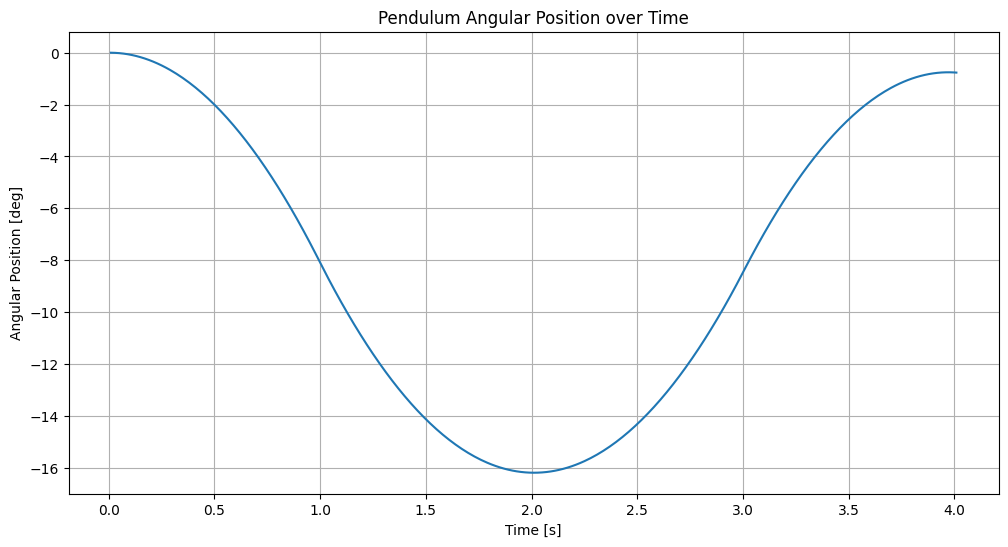

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(myPendulum._time_history, np.rad2deg(myPendulum._theta_history))
plt.xlabel('Time [s]')
plt.ylabel('Angular Position [deg]')
plt.title('Pendulum Angular Position over Time')
plt.grid()
plt.show()

In [30]:
init_theta = myPendulum._theta_history[0]
final_theta = myPendulum._theta_history[-1]
print(f"Initial angle: {np.rad2deg(init_theta):.4f} deg \\ Final angle: {np.rad2deg(final_theta):.4f} deg")
max_theta = max(myPendulum._theta_history, key=abs)
print(f"Max angle during simulation: {np.rad2deg(max_theta):.4f} deg")

relative_error = abs((final_theta - init_theta) / max_theta) if init_theta != 0 else float('inf')
print(f"Relative error: {relative_error:.4e}")

Initial angle: -0.0004 deg \ Final angle: -0.7668 deg
Max angle during simulation: -16.1957 deg
Relative error: 4.7319e-02


In [31]:
# Analytical solution
dt = 1 # s
torque = -10 # Nm
inertia = myPendulum._J # kg m^2
alpha = torque / inertia # rad/s^2

q0 = 0
final_q = q0 + 0.5 * alpha * dt**2
print(f"Analytical solution after {dt} s: {np.rad2deg(final_q):.4f} deg")

error = abs(final_q - final_theta)
print(f"Absolute error between FEM and analytical solution: {np.rad2deg(error):.4e} deg")

Analytical solution after 1 s: -40.9248 deg
Absolute error between FEM and analytical solution: 4.0158e+01 deg
